<a href="https://colab.research.google.com/github/zzzzzssyy/ECON3916-33674-Statistical-Machine-Learning/blob/main/Assignment%203/The%20Causal%20Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

Phase 1: Bootstrapping Non-Parametric Uncertainty

In [40]:
# Data Generating Process
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

In [43]:
n_bootstrap = 10000
bootstrap_medians = np.zeros(n_bootstrap)
for i in range(n_bootstrap):
  resample = np.random.choice(driver_tips, size=len(driver_tips), replace=True)
  bootstrap_medians[i] = np.median(resample)

ci_lower = np.percentile(bootstrap_medians, 2.5)
ci_upper = np.percentile(bootstrap_medians, 97.5)


print(f"Bootstrap meidan mean: {np.mean(bootstrap_medians):.4f}")
print(f"95% Confidence Interval:[{ci_lower:.4f}，{ci_upper:.4f}]")
print(f"Interval width {ci_upper - ci_lower:.4f}")

Bootstrap meidan mean: 0.7694
95% Confidence Interval:[0.2643，1.3664]
Interval width 1.1021


Phase 2: Falsification in Logistics A/B Testing

In [44]:
np.random.seed(42)
control = np.random.normal(loc=35, scale=5, size=500)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)

observed_diff = np.mean(control) - np.mean(treatment)
print(f"Observed Difference: {observed_diff:.4f}")

Observed Difference: 2.2650


In [45]:
from numpy.random.mtrand import permutation
combined = np.concatenate([control, treatment])

n_permutations = 5000
perm_diffs = np.zeros(n_permutations)

for i in range(n_permutations):
  shuffled = np.random.permutation(combined)
  perm_diffs[i] = np.mean(shuffled[:500]) - np.mean(shuffled[500:])

p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print(f"p-value: {p_value:.4f}")
print(f"Observed Difference: {observed_diff:.4f}")

p-value: 0.0004
Observed Difference: 2.2650


Phase 3: Causal Control and the Mitigation of Selection Bias

In [38]:
df = pd.read_csv('swiftcart_loyalty.csv')

subscribers = df[df['subscriber']==1]['post_spend']
non_subscribers = df[df['subscriber']==0]['post_spend']
Diff_means = subscribers.mean() - non_subscribers.mean()

print(f"Subscriber Mean: {subscribers.mean():.4f}")
print(f"Non-Subscriber Mean: {non_subscribers.mean():.4f}")
print(f"Difference in Means: {Diff_means:.4f}")

Subscriber Mean: 74.0436
Non-Subscriber Mean: 56.4729
Difference in Means: 17.5707


In [60]:
X = df[["pre_spend","account_age","support_tickets"]]
Y = df["subscriber"]

model = LogisticRegression()
model.fit(X,Y)
df['propensity_score'] = model.predict_proba(X)[:,1]

subscribers = df[df['subscriber']==1]
non_subscribers = df[df['subscriber']==0]

Nearest_Neigh = NearestNeighbors(n_neighbors=1)
Nearest_Neigh.fit(non_subscribers[['propensity_score']])
distances, indices = Nearest_Neigh.kneighbors(subscribers[['propensity_score']])
matched_control = non_subscribers.iloc[indices.flatten()]

ATT = np.mean(subscribers['post_spend']) - np.mean(matched_control['post_spend'])
print(f"Average Treatment Effect on the Treated: {ATT:.2f}")

Average Treatment Effect on the Treated: 9.91


Phase 4: AI Expansion (The Co-Pilot Era)

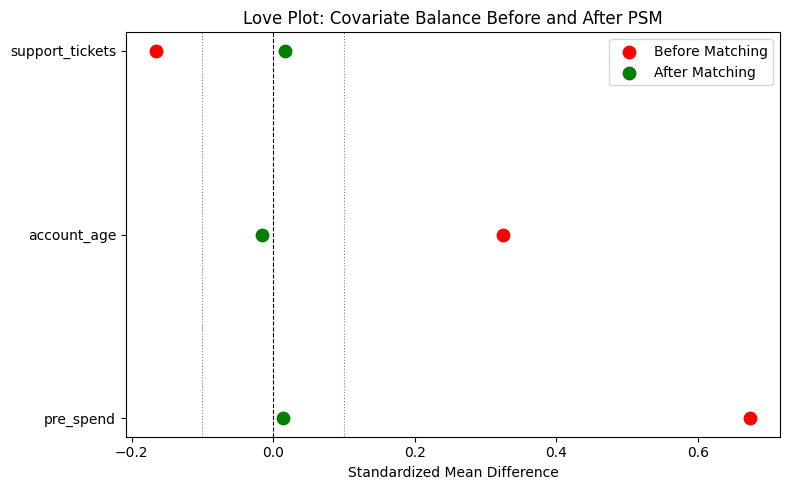

In [61]:
df_unmatched = df.copy()
df_matched = pd.concat([subscribers, matched_control]).reset_index(drop=True)

import matplotlib.pyplot as plt
import seaborn as sns

covariates = ['pre_spend', 'account_age', 'support_tickets']

def standardized_mean_diff(df, covariates):
    treated = df[df['subscriber'] == 1]
    control = df[df['subscriber'] == 0]
    smd = []
    for col in covariates:
        diff = treated[col].mean() - control[col].mean()
        pooled_std = np.sqrt((treated[col].std()**2 + control[col].std()**2) / 2)
        smd.append(diff / pooled_std)
    return smd

smd_before = standardized_mean_diff(df_unmatched, covariates)
smd_after = standardized_mean_diff(df_matched, covariates)

fig, ax = plt.subplots(figsize=(8, 5))
y = range(len(covariates))

ax.scatter(smd_before, y, color='red', label='Before Matching', s=80, zorder=3)
ax.scatter(smd_after, y, color='green', label='After Matching', s=80, zorder=3)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(0.1, color='gray', linewidth=0.8, linestyle=':')
ax.axvline(-0.1, color='gray', linewidth=0.8, linestyle=':')

ax.set_yticks(y)
ax.set_yticklabels(covariates)
ax.set_xlabel('Standardized Mean Difference')
ax.set_title('Love Plot: Covariate Balance Before and After PSM')
ax.legend()
plt.tight_layout()
plt.show()